# Tópicos em Otimização Irrestrita

<p style="color: blue; font-size: 22px; font-weight: bold; text-align: center;">
Aluno: Alessandro da Silva Maciel (aluno especial)
</p>

### Machine epsilon

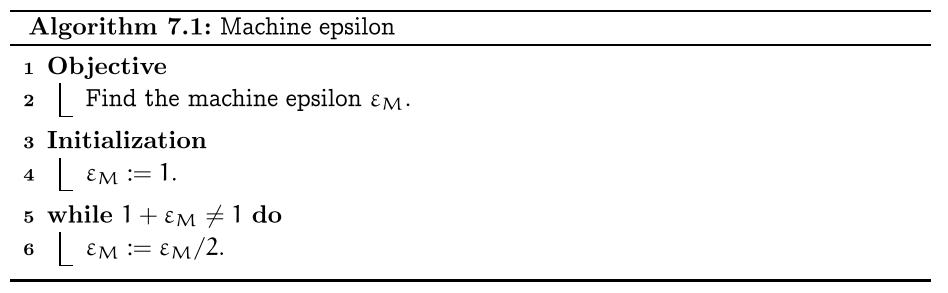

In [11]:
epsilon = 1.0
k = 0

while 1.0 + epsilon != 1.0
    epsilon = epsilon / 2
    k += 1
end

epsilon = epsilon * 2

println("Machine epsilon = ", epsilon)
println("Número de iterações = ", k)

Machine epsilon = 2.220446049250313e-16
Número de iterações = 53


### Newton's method: one variable

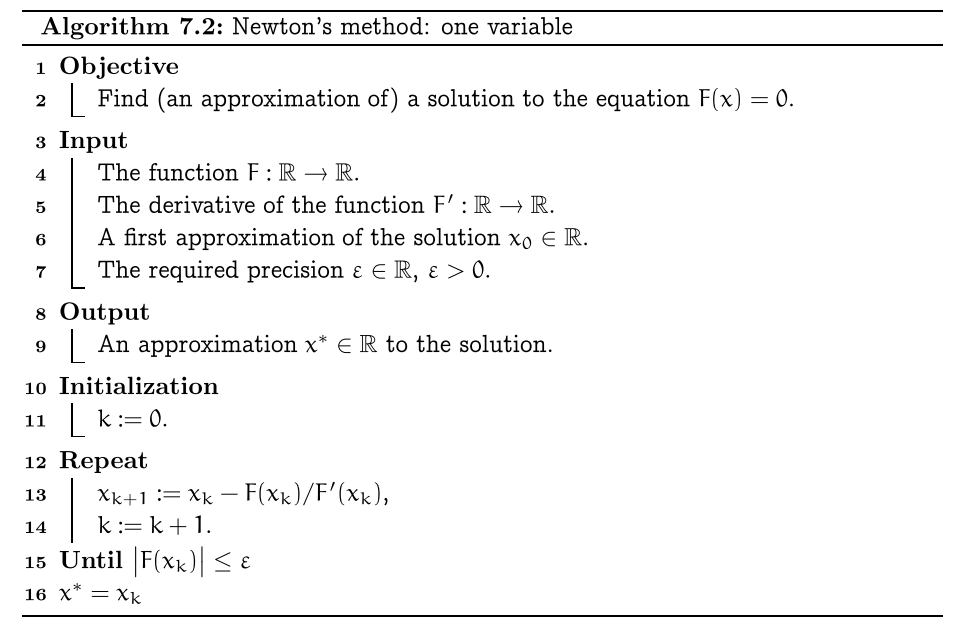

Take the equation: $F(x) = x^2 - 2 = 0$. Apply the Newton's method with $x_0 = 2, \epsilon = 10^{-15}$. Present the results such as the following:

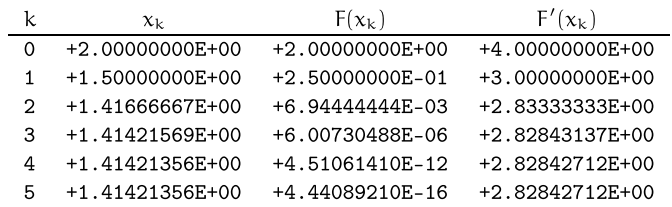

Also plot the graph with the iterations $\times$ the value of F(x).

k   x_k                    F(x_k)                 F'(x_k)               
0   +2.000000000000000e+00 +2.000000000000000e+00 +4.000000000000000e+00
1   +1.500000000000000e+00 +2.500000000000000e-01 +3.000000000000000e+00
2   +1.416666666666667e+00 +6.944444444444642e-03 +2.833333333333333e+00
3   +1.414215686274510e+00 +6.007304882871267e-06 +2.828431372549020e+00
4   +1.414213562374690e+00 +4.510614104447086e-12 +2.828427124749380e+00
5   +1.414213562373095e+00 +4.440892098500626e-16 +2.828427124746190e+00

Aproximação final: x* = 1.414213562373095


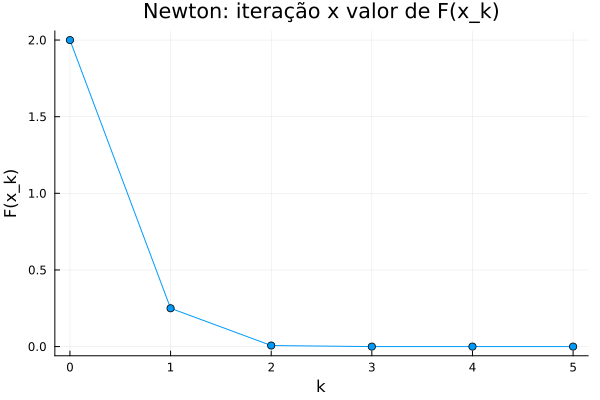

In [3]:
using Printf
using Plots

# Função e derivada
F(x) = x^2 - 2
dF(x) = 2x

# Dados do problema
x0 = 2.0
eps = 1e-15

# Vetores para armazenar as iterações
ks = Int[]
xs = Float64[]
fxs = Float64[]
dfxs = Float64[]

# Método de Newton
x = x0
k = 0

while true
    fx = F(x)
    dfx = dF(x)

    push!(ks, k)
    push!(xs, x)
    push!(fxs, fx)
    push!(dfxs, dfx)

    if abs(fx) <= eps
        break
    end

    x = x - fx/dfx
    k += 1
end

# Tabela de resultados
@printf("%-3s %-22s %-22s %-22s\n", "k", "x_k", "F(x_k)", "F'(x_k)")
for i in eachindex(ks)
    @printf("%-3d %+ .15e %+ .15e %+ .15e\n", ks[i], xs[i], fxs[i], dfxs[i])
end

# Aproximação final
@printf("\nAproximação final: x* = %.15f\n", xs[end])

# Gráfico: iteração k versus F(x_k)
plot(ks, fxs,
     marker = :circle,
     xlabel = "k",
     ylabel = "F(x_k)",
     title = "Newton: iteração x valor de F(x_k)",
     legend = false,
     grid = true)

Another example: $F(x)=x-\sin(x)$. Run the example with $x_0=1$ and $\varepsilon=10^{-15}$.

k   x_k                    F(x_k)                 F'(x_k)               
0   +1.000000000000000e+00 +1.585290151921035e-01 +4.596976941318602e-01
1   +6.551450720424304e-01 +4.587078604089578e-02 +2.070404522188284e-01
2   +4.335903683634927e-01 +1.345873795940100e-02 +9.253682546673025e-02
3   +2.881484008925012e-01 +3.970948460417290e-03 +4.122829853545917e-02
4   +1.918323121506386e-01 +1.174396923293297e-03 +1.834346161136258e-02
5   +1.278096675607083e-01 +3.476843492049853e-04 +8.156543180431908e-03
6   +8.518323360286406e-02 +1.029801567549449e-04 +3.625898332586197e-03
7   +5.678195278661637e-02 +3.050771704538047e-05 +1.611661985920665e-03
8   +3.785260078111326e-02 +9.038675803818563e-06 +7.163241565578682e-04
9   +2.523446453501505e-02 +2.678040884988853e-06 +3.183722052731985e-04
10  +1.682279781087122e-02 +7.934823667461732e-07 +1.414999259286009e-04
11  +1.121514564046264e-02 +2.351044078308107e-07 +6.288908668450333e-05
12  +7.476748086523549e-03 +6.966037057430652e-08 +

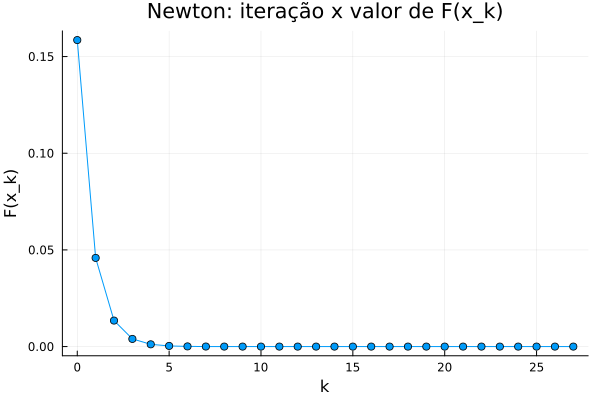

In [4]:
using Printf
using Plots

F(x) = x - sin(x)
dF(x) = 1 - cos(x)

x0 = 1.0
eps = 1e-15

ks = Int[]
xs = Float64[]
fxs = Float64[]
dfxs = Float64[]

x = x0
k = 0
maxiter = 200

while true
    fx = F(x)
    dfx = dF(x)

    push!(ks, k)
    push!(xs, x)
    push!(fxs, fx)
    push!(dfxs, dfx)

    if abs(fx) <= eps || k >= maxiter
        break
    end

    x = x - fx / dfx
    k += 1
end

@printf("%-3s %-22s %-22s %-22s\n", "k", "x_k", "F(x_k)", "F'(x_k)")
for i in eachindex(ks)
    @printf("%-3d %+ .15e %+ .15e %+ .15e\n", ks[i], xs[i], fxs[i], dfxs[i])
end

@printf("\nAproximação final: x* = %.15e\n", xs[end])

plot(ks, fxs,
    marker = :circle,
    xlabel = "k",
    ylabel = "F(x_k)",
    title = "Newton: iteração x valor de F(x_k)",
    legend = false,
    grid = true)

Another example: $F(x)=\arctan(x)$. Run the example with $x_0=1.5$ and $\varepsilon=10^{-15}$. We set `maxiter` to 10, as the algorithm is not converging.

k   x_k                    F(x_k)                 F'(x_k)               
0   +1.500000000000000e+00 +9.827937232473291e-01 +3.076923076923077e-01
1   -1.694079600553819e+00 -1.037546359137891e+00 +2.584042297995987e-01
2   +2.321126961438388e+00 +1.164002042421975e+00 +1.565525777010881e-01
3   -5.114087836777514e+00 -1.377694528702752e+00 +3.682713003097605e-02
4   +3.229568391421002e+01 +1.539842326908012e+00 +9.578441308788566e-04
5   -1.575316950821204e+03 -1.570161533990085e+00 +4.029618509147333e-07
6   +3.894976007760884e+06 +1.570796070053906e+00 +6.591593643938818e-14
7   -2.383028897355212e+13 -1.570796326794855e+00 +1.760927121594930e-27
8   +8.920280161123818e+26 +1.570796326794897e+00 +1.256732975934346e-54
9   -1.249904599365711e+54 -1.570796326794897e+00 +6.400977014343046e-109
10  +2.453994637498496e+108 +1.570796326794897e+00 +1.660553151801127e-217

Último valor calculado: x = 2.453994637498496e+108


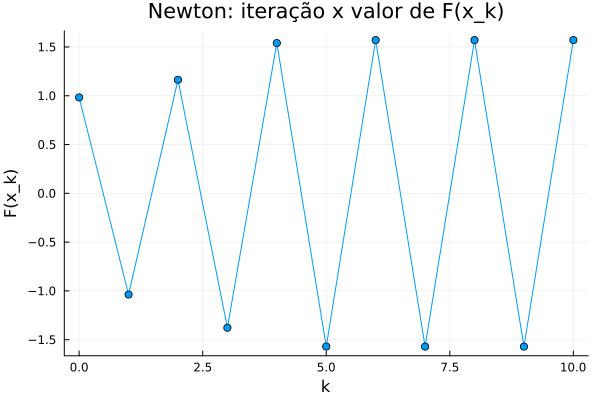

In [5]:
using Printf
using Plots

F(x) = atan(x)
dF(x) = 1 / (1 + x^2)

x0 = 1.5
eps = 1e-15
maxiter = 10

ks = Int[]
xs = Float64[]
fxs = Float64[]
dfxs = Float64[]

x = x0

for k in 0:maxiter
    fx = F(x)
    dfx = dF(x)

    push!(ks, k)
    push!(xs, x)
    push!(fxs, fx)
    push!(dfxs, dfx)

    if abs(fx) <= eps
        break
    end

    x = x - fx / dfx
end

@printf("%-3s %-22s %-22s %-22s\n", "k", "x_k", "F(x_k)", "F'(x_k)")
for i in eachindex(ks)
    @printf("%-3d %+ .15e %+ .15e %+ .15e\n", ks[i], xs[i], fxs[i], dfxs[i])
end

@printf("\nÚltimo valor calculado: x = %.15e\n", xs[end])

plot(ks, fxs,
    marker = :circle,
    xlabel = "k",
    ylabel = "F(x_k)",
    title = "Newton: iteração x valor de F(x_k)",
    legend = false,
    grid = true)

### Algorithm 7.3: Newton's method: $n$ variables

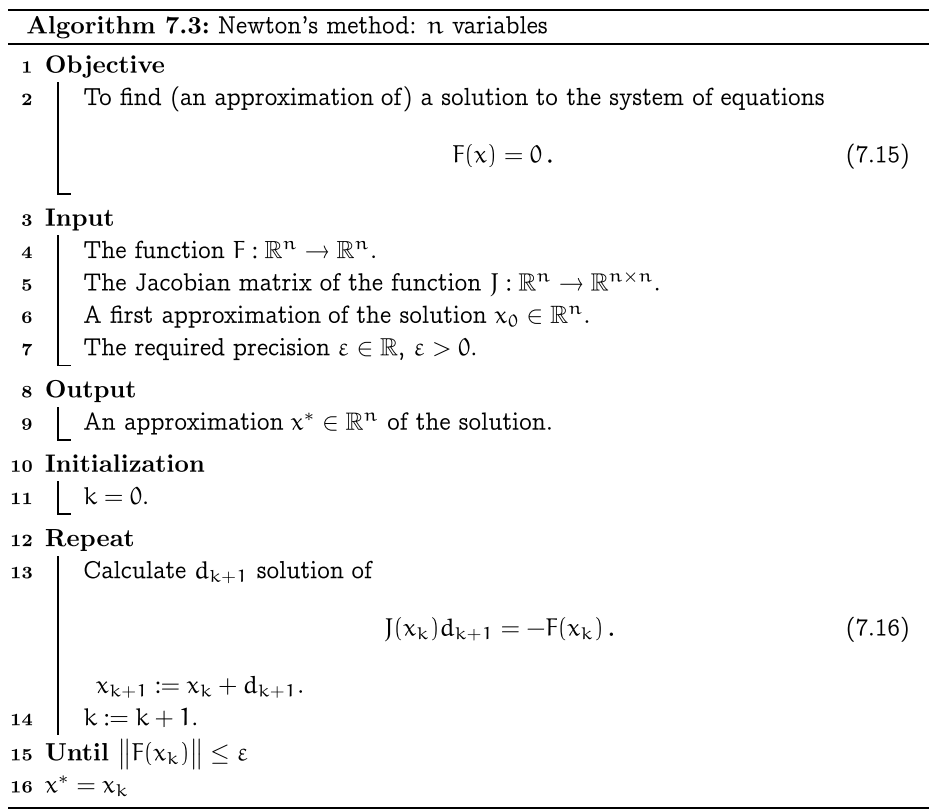

Example: $F(x)=\left(\begin{array}{c}(x_1+1)^2+ x_2^2 - 2 \\ e^{x_1} + x_2^3 - 2 \end{array}\right)$. Run the example with $x_0= \left(\begin{array}{c} 1 \\ 1 \end{array}\right)$ and $\varepsilon = 10^{-15}$

k   x1_k                   x2_k                   F1(x_k)                F2(x_k)                ||F(x_k)||2           
0   +1.000000000000000e+00 +1.000000000000000e+00 +3.000000000000000e+00 +1.718281828459045e+00 +3.457237689545305e+00
1   +1.523592136387572e-01 +1.195281572722486e+00 +7.566297953480730e-01 +8.722749316977847e-01 +1.154708709448769e+00
2   -1.083768093614593e-02 +1.036111167258880e+00 +5.196844437434134e-02 +1.015134756776370e-01 +1.140425576477624e-01
3   -8.896646014696693e-04 +1.001535316494101e+00 +1.294452485103292e-03 +3.723755724303945e-03 +3.942329759225691e-03
4   -1.370088751057388e-06 +1.000002938707905e+00 +3.137248821172278e-06 +7.446061810689741e-06 +8.079985560293969e-06
5   -5.538452196134216e-12 +1.000000000010795e+00 +1.051292386478053e-11 +2.684608091385599e-11 +2.883112256954236e-11
6   -1.046379357426522e-16 +1.000000000000000e+00 +0.000000000000000e+00 +4.440892098500626e-16 +4.440892098500626e-16

Solução aproximada:
x* = [-0.000000000000000, 1

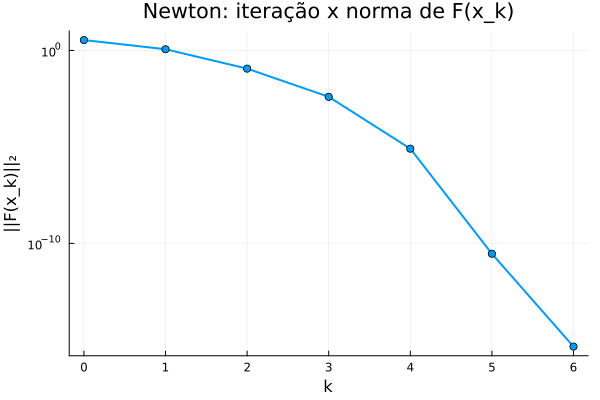

In [6]:
using LinearAlgebra
using Printf
using Plots

# ============================================================
# Método de Newton para sistema não linear em 2 variáveis
# Exemplo:
# F(x) = [ (x1+1)^2 + x2^2 - 2
#          exp(x1) + x2^3  - 2 ]
# x0 = [1, 1], eps = 1e-15
# ============================================================

# --------------------------
# Sistema F(x)
# --------------------------
function F(x::Vector{Float64})
    x1, x2 = x
    return [
        (x1 + 1)^2 + x2^2 - 2
        exp(x1) + x2^3 - 2
    ]
end

# --------------------------
# Jacobiana J(x)
# --------------------------
function J(x::Vector{Float64})
    x1, x2 = x
    return [
        2 * (x1 + 1)   2 * x2
        exp(x1)        3 * x2^2
    ]
end

# --------------------------
# Parâmetros
# --------------------------
x = [1.0, 1.0]
eps = 1e-15
maxiter = 50

# --------------------------
# Armazenamento das iterações
# --------------------------
ks    = Int[]
x1s   = Float64[]
x2s   = Float64[]
f1s   = Float64[]
f2s   = Float64[]
norms = Float64[]

# --------------------------
# Iteração de Newton
# --------------------------
for k in 0:maxiter
    Fx = F(x)
    nFx = norm(Fx, 2)

    push!(ks, k)
    push!(x1s, x[1])
    push!(x2s, x[2])
    push!(f1s, Fx[1])
    push!(f2s, Fx[2])
    push!(norms, nFx)

    if nFx <= eps
        break
    end

    d = J(x) \ (-Fx)
    x = x + d
end

# --------------------------
# Impressão da tabela
# --------------------------
@printf("%-3s %-22s %-22s %-22s %-22s %-22s\n",
        "k", "x1_k", "x2_k", "F1(x_k)", "F2(x_k)", "||F(x_k)||2")

for i in eachindex(ks)
    @printf("%-3d %+ .15e %+ .15e %+ .15e %+ .15e %+ .15e\n",
            ks[i], x1s[i], x2s[i], f1s[i], f2s[i], norms[i])
end

# --------------------------
# Solução final
# --------------------------
@printf("\nSolução aproximada:\n")
@printf("x* = [%.15f, %.15f]\n", x1s[end], x2s[end])

# --------------------------
# Gráfico sem erro de log(0)
# --------------------------
idx = findall(v -> v > 0.0, norms)

plot(ks[idx], norms[idx],
    marker = :circle,
    xlabel = "k",
    ylabel = "||F(x_k)||₂",
    title = "Newton: iteração x norma de F(x_k)",
    legend = false,
    grid = true,
    yscale = :log10,
    lw = 2)

Example: $F(x)=\left(\begin{array}{c}x_1^3 - 3 x_1 x_2^2 -1 \\ x_2^3 - 3x_1^2 x_2\end{array}\right)$. Run the example with $x_0= \left(\begin{array}{c} 1 \\ 1 \end{array}\right)$ and $\varepsilon = 10^{-15}$

k   x1_k                   x2_k                   F1(x_k)                F2(x_k)                ||F(x_k)||2           
0   +1.000000000000000e+00 +1.000000000000000e+00 -3.000000000000000e+00 -2.000000000000000e+00 +3.605551275463989e+00
1   +6.666666666666667e-01 +5.000000000000000e-01 -1.203703703703704e+00 -5.416666666666667e-01 +1.319964160152764e+00
2   +5.788444444444445e-01 -1.274666666666667e-01 -8.342666261688011e-01 +1.260562379915063e-01 +8.437363205857891e-01
3   +1.246963981575016e+00 +3.135784251549973e-01 +5.710809513061967e-01 -1.431932700419327e+00 +1.541611076593242e+00
4   +1.008948197751505e+00 +1.136779651549011e-01 -1.202942289935716e-02 -3.456954556650876e-01 +3.459046907499002e-01
5   +9.878680459783756e-01 +3.836843642864726e-03 -3.599972308348542e-02 -1.123287815055605e-02 +3.771150505658549e-02
6   +1.000134144210213e+00 -9.532218509626829e-05 +4.024593544460497e-04 +2.860432810839636e-04 +4.937552942849429e-04
7   +1.000000008910006e+00 -2.556813290268919e-0

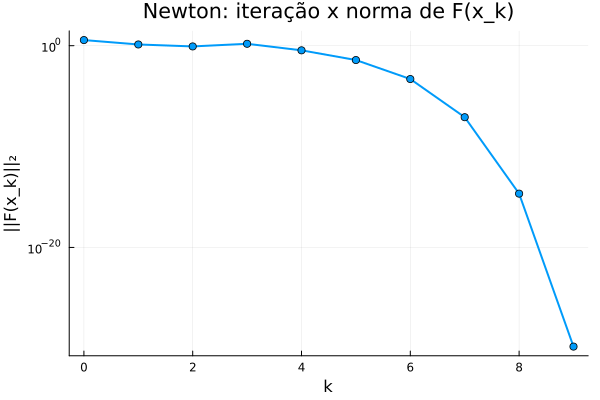

In [7]:
using LinearAlgebra
using Printf
using Plots

# ============================================================
# Método de Newton para sistema não linear em 2 variáveis
# Exemplo:
# F(x) = [ x1^3 - 3*x1*x2^2 - 1
#          x2^3 - 3*x1^2*x2 ]
# x0 = [1, 1], eps = 1e-15
# ============================================================

# Sistema F(x)
function F(x::Vector{Float64})
    x1, x2 = x
    return [
        x1^3 - 3*x1*x2^2 - 1
        x2^3 - 3*x1^2*x2
    ]
end

# Jacobiana J(x)
function J(x::Vector{Float64})
    x1, x2 = x
    return [
        3*x1^2 - 3*x2^2    -6*x1*x2
        -6*x1*x2           3*x2^2 - 3*x1^2
    ]
end

# Parâmetros
x = [1.0, 1.0]
eps = 1e-15
maxiter = 50

# Armazenamento
ks    = Int[]
x1s   = Float64[]
x2s   = Float64[]
f1s   = Float64[]
f2s   = Float64[]
norms = Float64[]

# Iterações
for k in 0:maxiter
    Fx = F(x)
    nFx = norm(Fx, 2)

    push!(ks, k)
    push!(x1s, x[1])
    push!(x2s, x[2])
    push!(f1s, Fx[1])
    push!(f2s, Fx[2])
    push!(norms, nFx)

    if nFx <= eps
        break
    end

    d = J(x) \ (-Fx)
    x = x + d
end

# Tabela
@printf("%-3s %-22s %-22s %-22s %-22s %-22s\n",
        "k", "x1_k", "x2_k", "F1(x_k)", "F2(x_k)", "||F(x_k)||2")

for i in eachindex(ks)
    @printf("%-3d %+ .15e %+ .15e %+ .15e %+ .15e %+ .15e\n",
            ks[i], x1s[i], x2s[i], f1s[i], f2s[i], norms[i])
end

# Solução final
@printf("\nSolução aproximada:\n")
@printf("x* = [%.15f, %.15e]\n", x1s[end], x2s[end])

# Gráfico em escala log, sem plotar eventual zero final
idx = findall(v -> v > 0.0, norms)

plot(ks[idx], norms[idx],
    marker = :circle,
    xlabel = "k",
    ylabel = "||F(x_k)||₂",
    title = "Newton: iteração x norma de F(x_k)",
    legend = false,
    grid = true,
    yscale = :log10,
    lw = 2)

Run the example with $x_0= \left(\begin{array}{c} -1 \\ -1 \end{array}\right)$ and $\varepsilon = 10^{-15}$

k   x1_k                   x2_k                   F1(x_k)                F2(x_k)                ||F(x_k)||2           
0   -1.000000000000000e+00 -1.000000000000000e+00 +1.000000000000000e+00 +2.000000000000000e+00 +2.236067977499790e+00
1   -6.666666666666667e-01 -8.333333333333334e-01 +9.259259259259256e-02 +5.324074074074076e-01 +5.403989597189238e-01
2   -5.086919161874546e-01 -8.410998744133783e-01 -5.201215760112488e-02 +5.791258444874536e-02 +7.784042635968354e-02
3   -4.993299956437513e-01 -8.662691717880057e-01 -3.731113912235351e-04 -2.105852141383702e-03 +2.138650357499113e-03
4   -4.999999113699129e-01 -8.660249031568892e-01 -1.433613062817862e-06 +5.206731056306424e-07 +1.525236669113705e-06
5   -4.999999999999554e-01 -8.660254037846932e-01 +5.946354519892338e-13 -4.974909373345326e-13 +7.752990090877405e-13
6   -4.999999999999999e-01 -8.660254037844386e-01 -2.220446049250313e-16 -1.110223024625157e-16 +2.482534153247273e-16

Solução aproximada:
x* = [-0.500000000000000, -

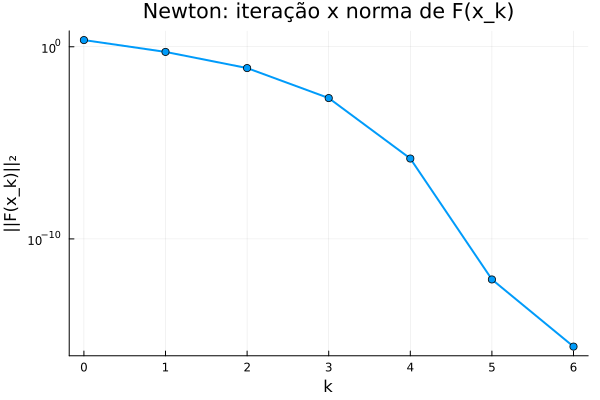

In [8]:
using LinearAlgebra
using Printf
using Plots

function F(x::Vector{Float64})
    x1, x2 = x
    return [
        x1^3 - 3*x1*x2^2 - 1
        x2^3 - 3*x1^2*x2
    ]
end

function J(x::Vector{Float64})
    x1, x2 = x
    return [
        3*x1^2 - 3*x2^2    -6*x1*x2
        -6*x1*x2           3*x2^2 - 3*x1^2
    ]
end

x = [-1.0, -1.0]
eps = 1e-15
maxiter = 50

ks    = Int[]
x1s   = Float64[]
x2s   = Float64[]
f1s   = Float64[]
f2s   = Float64[]
norms = Float64[]

for k in 0:maxiter
    Fx = F(x)
    nFx = norm(Fx, 2)

    push!(ks, k)
    push!(x1s, x[1])
    push!(x2s, x[2])
    push!(f1s, Fx[1])
    push!(f2s, Fx[2])
    push!(norms, nFx)

    if nFx <= eps
        break
    end

    d = J(x) \ (-Fx)
    x = x + d
end

@printf("%-3s %-22s %-22s %-22s %-22s %-22s\n",
        "k", "x1_k", "x2_k", "F1(x_k)", "F2(x_k)", "||F(x_k)||2")

for i in eachindex(ks)
    @printf("%-3d %+ .15e %+ .15e %+ .15e %+ .15e %+ .15e\n",
            ks[i], x1s[i], x2s[i], f1s[i], f2s[i], norms[i])
end

@printf("\nSolução aproximada:\n")
@printf("x* = [%.15f, %.15f]\n", x1s[end], x2s[end])

idx = findall(v -> v > 0.0, norms)

plot(ks[idx], norms[idx],
    marker = :circle,
    xlabel = "k",
    ylabel = "||F(x_k)||₂",
    title = "Newton: iteração x norma de F(x_k)",
    legend = false,
    grid = true,
    yscale = :log10,
    lw = 2)

Run the example with $x_0= \left(\begin{array}{c} 0 \\ 1 \end{array}\right)$ and $\varepsilon = 10^{-15}$

k   x1_k                   x2_k                   F1(x_k)                F2(x_k)                ||F(x_k)||2           
0   +0.000000000000000e+00 +1.000000000000000e+00 -1.000000000000000e+00 +1.000000000000000e+00 +1.414213562373095e+00
1   -3.333333333333333e-01 +6.666666666666667e-01 -5.925925925925926e-01 +7.407407407407415e-02 +5.972042776517444e-01
2   -5.822222222222222e-01 +9.244444444444444e-01 +2.953337503429352e-01 -1.500841262002744e-01 +3.312812536635948e-01
3   -5.087908032893191e-01 +8.681655118873491e-01 +1.873451971095919e-02 -1.987481626730536e-02 +2.731282758081748e-02
4   -5.000687390673927e-01 +8.659822186925401e-01 -9.109273752638813e-06 -2.433654983675648e-04 +2.435359206852117e-04
5   -4.999999962890297e-01 +8.660253983385868e-01 -1.971519347776507e-08 +1.472605926089443e-09 +1.977011436687365e-08
6   -5.000000000000001e-01 +8.660254037844387e-01 +4.440892098500626e-16 -2.220446049250313e-16 +4.965068306494546e-16

Solução aproximada:
x* = [-0.500000000000000, 0

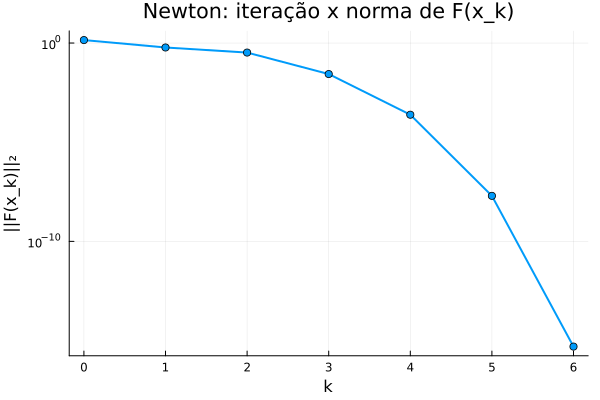

In [9]:
using LinearAlgebra
using Printf
using Plots

function F(x::Vector{Float64})
    x1, x2 = x
    return [
        x1^3 - 3*x1*x2^2 - 1
        x2^3 - 3*x1^2*x2
    ]
end

function J(x::Vector{Float64})
    x1, x2 = x
    return [
        3*x1^2 - 3*x2^2    -6*x1*x2
        -6*x1*x2           3*x2^2 - 3*x1^2
    ]
end

x = [0.0, 1.0]
eps = 1e-15
maxiter = 50

ks    = Int[]
x1s   = Float64[]
x2s   = Float64[]
f1s   = Float64[]
f2s   = Float64[]
norms = Float64[]

for k in 0:maxiter
    Fx = F(x)
    nFx = norm(Fx, 2)

    push!(ks, k)
    push!(x1s, x[1])
    push!(x2s, x[2])
    push!(f1s, Fx[1])
    push!(f2s, Fx[2])
    push!(norms, nFx)

    if nFx <= eps
        break
    end

    d = J(x) \ (-Fx)
    x = x + d
end

@printf("%-3s %-22s %-22s %-22s %-22s %-22s\n",
        "k", "x1_k", "x2_k", "F1(x_k)", "F2(x_k)", "||F(x_k)||2")

for i in eachindex(ks)
    @printf("%-3d %+ .15e %+ .15e %+ .15e %+ .15e %+ .15e\n",
            ks[i], x1s[i], x2s[i], f1s[i], f2s[i], norms[i])
end

@printf("\nSolução aproximada:\n")
@printf("x* = [%.15f, %.15f]\n", x1s[end], x2s[end])

idx = findall(v -> v > 0.0, norms)

plot(ks[idx], norms[idx],
    marker = :circle,
    xlabel = "k",
    ylabel = "||F(x_k)||₂",
    title = "Newton: iteração x norma de F(x_k)",
    legend = false,
    grid = true,
    yscale = :log10,
    lw = 2)